In [1]:
import xarray as xr
import os
import glob
import geopandas as gpd
import pandas as pd
import numpy as np
from scipy.stats import linregress
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.ticker import MaxNLocator

In [2]:
path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files'
pattern=f'ROS_Monthly*.nc'
file_list = sorted(glob.glob(os.path.join(path, pattern)))
data = xr.open_mfdataset(file_list, combine='by_coords',engine='netcdf4')

In [3]:
!hostname

n20.clstr


In [4]:
data_seasonal = data.sum(dim="month")
data_seasonal

<xarray.Dataset> Size: 1GB
Dimensions:              (season: 73, south_north: 450, west_east: 420,
                          interp_level: 3)
Coordinates:
  * season               (season) <U9 3kB '1950-1951' ... '2022-2023'
    XLAT                 (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    XLONG                (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
  * interp_level         (interp_level) float64 24B 850.0 925.0 950.0
Dimensions without coordinates: south_north, west_east
Data variables: (12/13)
    ros_tally            (season, south_north, west_east) int64 110MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    ros_counts           (season, south_north, west_east) int64 110MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    ros_days_count       (season, south_north, west_east) int64 110MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    rain_sum             (season, south_north, west_east) float32 55MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    rain_ros_sum         (season, south_north, west_east) float32 55MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    rain_avg             (season, south_north, west_east) float32 55MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    ...                   ...
    swe_avg              (season, south_north, west_east) float32 55MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    swe_ros_avg          (season, south_north, west_east) float32 55MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    T2_avg               (season, south_north, west_east) float32 55MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    T2_ros_avg           (season, south_north, west_east) float32 55MB dask.array<chunksize=(1, 450, 420), meta=np.ndarray>
    temp_levels_avg      (season, interp_level, south_north, west_east) float32 166MB dask.array<chunksize=(1, 2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg  (season, interp_level, south_north, west_east) float32 166MB dask.array<chunksize=(1, 2, 450, 420), meta=np.ndarray>

In [5]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)
FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)
lat=data['XLAT']
lon=data['XLONG']
seasons=data['season']

In [6]:
seasonslist = seasons.values.tolist()

In [7]:
x_numeric = xr.DataArray(
    np.arange(len(data['season'])),  # 0,1,2,...,72
    dims=['season'],
    coords={'season': data['season']})

NEW COMBINED ON JULY 22
-

In [8]:

import numpy as np
import xarray as xr
from scipy import stats


# ==========================================================
# Theil-Sen regression
# ==========================================================

def new_theilsen(x, y):
    """
    Theil-Sen trend estimator

    Returns:
    slope,
    intercept,
    low_slope,
    high_slope,
    pct_change
    """

    try:

        mask = np.isfinite(x) & np.isfinite(y)

        if np.sum(mask) < 2:
            return np.full(5, np.nan)

        x = x[mask]
        y = y[mask]

        slope, intercept, low_slope, high_slope = stats.theilslopes(
            y, x
        )

        # fitted start/end values
        start_fit = intercept + slope * x[0]
        end_fit = intercept + slope * x[-1]

        if start_fit != 0:
            pct_change = (
                (end_fit - start_fit) /
                start_fit
            ) * 100
        else:
            pct_change = np.nan


        return np.array([
            slope,
            intercept,
            low_slope,
            high_slope,
            pct_change
        ])


    except Exception:

        return np.full(5, np.nan)


def xr_theilsen(x, y, dim):

    if x.chunks is not None:
        x = x.chunk({dim: -1})

    if y.chunks is not None:
        y = y.chunk({dim: -1})


    res = xr.apply_ufunc(
        new_theilsen,
        x,
        y,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[['params']],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        output_sizes={'params':5},
    )


    res = res.assign_coords(
        params=[
            'slope',
            'intercept',
            'low_slope',
            'high_slope',
            'pct_change'
        ]
    )
    return res.to_dataset(dim='params')


def new_mannkendall(y):
    """
    Mann-Kendall trend test
    Returns:
    tau,
    p_value,
    S,
    var_S
    """
    try:
        y = np.asarray(y)
        mask = np.isfinite(y)
        y = y[mask]
        n = len(y)
        if n < 2:
            return np.full(4, np.nan)
        tau, p_value = stats.kendalltau(
            np.arange(n),
            y)

        # S statistic
        S = 0
        for k in range(n-1):
            S += np.sum(
                np.sign(
                    y[k+1:] - y[k]
                )
            )
        # variance (no tie correction)
        var_S = (
            n *
            (n-1) *
            (2*n+5)
        ) / 18

        return np.array([
            tau,
            p_value,
            S,
            var_S
        ])


    except Exception:

        return np.full(4, np.nan)

def xr_mannkendall(y, dim):

    if y.chunks is not None:
        y = y.chunk({dim:-1})
        
    res = xr.apply_ufunc(
        new_mannkendall,
        y,
        input_core_dims=[[dim]],
        output_core_dims=[['params']],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        output_sizes={'params':4},)


    res = res.assign_coords(
        params=[
            'tau',
            'p_value',
            'S',
            'var_S'
        ])


    return res.to_dataset(dim='params')

In [9]:
#MONTHLY
ts_list = []
mk_list = []

for var in data_seasonal.data_vars:
    ts = xr_theilsen(x_numeric, data[var], dim='season')
    mk = xr_mannkendall(data[var], dim='season')
    # Rename all variables inside returned Dataset
    ts = ts.rename({v: f"{var}_{v}_theilsen" for v in ts.data_vars})
    mk = mk.rename({v: f"{var}_{v}_mannkendall" for v in mk.data_vars})

    ts_list.append(ts)
    mk_list.append(mk)
combined = xr.merge(ts_list + mk_list)
#combined.to_netcdf("/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/NEWTEST_theilsen_trend_mannkndall_monthly_1950_2022.nc")

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1102180/617417820.py:72: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  res = xr.apply_ufunc(
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1102180/617417820.py:149: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  res = xr.apply_ufunc(
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1102180/617417820.py:72: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  res = xr.apply_ufunc(
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1102180/617417820.py:149: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  res = xr.apply_ufunc(
/center1/DYNDO

In [10]:
combined

<xarray.Dataset> Size: 1GB
Dimensions:                                  (month: 5, south_north: 450,
                                              west_east: 420, interp_level: 3)
Coordinates:
  * month                                    (month) int64 40B 11 12 1 2 3
    XLAT                                     (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    XLONG                                    (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    month_name                               (month) <U3 60B dask.array<chunksize=(5,), meta=np.ndarray>
  * interp_level                             (interp_level) float64 24B 850.0...
Dimensions without coordinates: south_north, west_east
Data variables: (12/117)
    ros_tally_slope_theilsen                 (month, south_north, west_east) float64 8MB dask.array<chunksize=(5, 450, 420), meta=np.ndarray>
    ros_tally_intercept_theilsen             (month, south_north, west_east) float64 8MB dask.array<chunksize=(5, 450, 420), meta=np.ndarray>
    ros_tally_low_slope_theilsen             (month, south_north, west_east) float64 8MB dask.array<chunksize=(5, 450, 420), meta=np.ndarray>
    ros_tally_high_slope_theilsen            (month, south_north, west_east) float64 8MB dask.array<chunksize=(5, 450, 420), meta=np.ndarray>
    ros_tally_pct_change_theilsen            (month, south_north, west_east) float64 8MB dask.array<chunksize=(5, 450, 420), meta=np.ndarray>
    ros_counts_slope_theilsen                (month, south_north, west_east) float64 8MB dask.array<chunksize=(5, 450, 420), meta=np.ndarray>
    ...                                       ...
    temp_levels_avg_S_mannkendall            (month, interp_level, south_north, west_east) float64 23MB dask.array<chunksize=(3, 2, 450, 420), meta=np.ndarray>
    temp_levels_avg_var_S_mannkendall        (month, interp_level, south_north, west_east) float64 23MB dask.array<chunksize=(3, 2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg_tau_mannkendall      (month, interp_level, south_north, west_east) float64 23MB dask.array<chunksize=(3, 2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg_p_value_mannkendall  (month, interp_level, south_north, west_east) float64 23MB dask.array<chunksize=(3, 2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg_S_mannkendall        (month, interp_level, south_north, west_east) float64 23MB dask.array<chunksize=(3, 2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg_var_S_mannkendall    (month, interp_level, south_north, west_east) float64 23MB dask.array<chunksize=(3, 2, 450, 420), meta=np.ndarray>

In [11]:
#SEASONAL
ts_list = []
mk_list = []
data_seasonal = data.sum(dim="month")
for var in data_seasonal.data_vars:
    print(f"Processing {var}")

    ts = xr_theilsen(
        x_numeric,
        data_seasonal[var],
        dim='season'
    )

    mk = xr_mannkendall(
        data_seasonal[var],
        dim='season'
    )

    ts = ts.rename(
        {v: f"{var}_{v}_theilsen" for v in ts.data_vars}
    )

    mk = mk.rename(
        {v: f"{var}_{v}_mannkendall" for v in mk.data_vars}
    )

    ts_list.append(ts)
    mk_list.append(mk)

combined_seasonal = xr.merge(ts_list + mk_list)

Processing ros_tally
Processing ros_counts
Processing ros_days_count
Processing rain_sum
Processing rain_ros_sum
Processing rain_avg
Processing rain_ros_avg
Processing swe_avg
Processing swe_ros_avg
Processing T2_avg
Processing T2_ros_avg
Processing temp_levels_avg
Processing temp_levels_ros_avg


/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1102180/617417820.py:72: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  res = xr.apply_ufunc(
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1102180/617417820.py:149: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  res = xr.apply_ufunc(
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1102180/617417820.py:72: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  res = xr.apply_ufunc(
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1102180/617417820.py:149: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  res = xr.apply_ufunc(
/center1/DYNDO

In [12]:
combined_seasonal

<xarray.Dataset> Size: 233MB
Dimensions:                                  (south_north: 450, west_east: 420,
                                              interp_level: 3)
Coordinates:
    XLAT                                     (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    XLONG                                    (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
  * interp_level                             (interp_level) float64 24B 850.0...
Dimensions without coordinates: south_north, west_east
Data variables: (12/117)
    ros_tally_slope_theilsen                 (south_north, west_east) float64 2MB dask.array<chunksize=(450, 420), meta=np.ndarray>
    ros_tally_intercept_theilsen             (south_north, west_east) float64 2MB dask.array<chunksize=(450, 420), meta=np.ndarray>
    ros_tally_low_slope_theilsen             (south_north, west_east) float64 2MB dask.array<chunksize=(450, 420), meta=np.ndarray>
    ros_tally_high_slope_theilsen            (south_north, west_east) float64 2MB dask.array<chunksize=(450, 420), meta=np.ndarray>
    ros_tally_pct_change_theilsen            (south_north, west_east) float64 2MB dask.array<chunksize=(450, 420), meta=np.ndarray>
    ros_counts_slope_theilsen                (south_north, west_east) float64 2MB dask.array<chunksize=(450, 420), meta=np.ndarray>
    ...                                       ...
    temp_levels_avg_S_mannkendall            (interp_level, south_north, west_east) float64 5MB dask.array<chunksize=(2, 450, 420), meta=np.ndarray>
    temp_levels_avg_var_S_mannkendall        (interp_level, south_north, west_east) float64 5MB dask.array<chunksize=(2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg_tau_mannkendall      (interp_level, south_north, west_east) float64 5MB dask.array<chunksize=(2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg_p_value_mannkendall  (interp_level, south_north, west_east) float64 5MB dask.array<chunksize=(2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg_S_mannkendall        (interp_level, south_north, west_east) float64 5MB dask.array<chunksize=(2, 450, 420), meta=np.ndarray>
    temp_levels_ros_avg_var_S_mannkendall    (interp_level, south_north, west_east) float64 5MB dask.array<chunksize=(2, 450, 420), meta=np.ndarray>

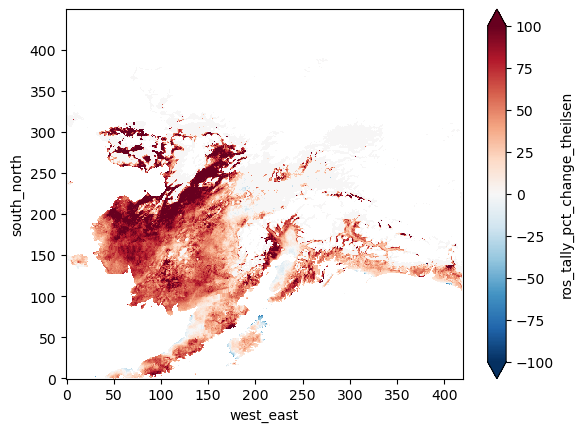

In [13]:
combined_seasonal['ros_tally_pct_change_theilsen'].plot(
    vmin=-100,
    vmax=100,
    cmap='RdBu_r'
)

In [21]:
ros_pct_monthly = combined['ros_tally_pct_change_theilsen'].compute()
ros_p_monthly = combined['ros_tally_p_value_mannkendall'].compute()

ros_pct_seasonal = combined_seasonal['ros_tally_pct_change_theilsen'].compute()
ros_p_seasonal = combined_seasonal['ros_tally_p_value_mannkendall'].compute()


KeyboardInterrupt: 

In [15]:
datasets = [
    (
        ros_pct_monthly.sel(month=11),
        ros_p_monthly.sel(month=11),
        "November"
    ),
    (
        ros_pct_monthly.sel(month=12),
        ros_p_monthly.sel(month=12),
        "December"
    ),
    (
        ros_pct_monthly.sel(month=1),
        ros_p_monthly.sel(month=1),
        "January"
    ),
    (
        ros_pct_monthly.sel(month=2),
        ros_p_monthly.sel(month=2),
        "February"
    ),
    (
        ros_pct_monthly.sel(month=3),
        ros_p_monthly.sel(month=3),
        "March"
    ),
    (
        ros_pct_seasonal,
        ros_p_seasonal,
        "Seasonal Total"
    )
]

NameError: name 'ros_p_seasonal' is not defined

In [22]:
import dask

(ros_pct_monthly,
 ros_p_monthly,
 ros_pct_seasonal,
 ros_p_seasonal) = dask.compute(
    combined['ros_tally_pct_change_theilsen'],
    combined['ros_tally_p_value_mannkendall'],
    combined_seasonal['ros_tally_pct_change_theilsen'],
    combined_seasonal['ros_tally_p_value_mannkendall'],
)

In [16]:
datasets = [
    (
        combined['ros_tally_pct_change_theilsen'].sel(month=11),
        combined['ros_tally_p_value_mannkendall'].sel(month=11),
        "November"
    ),
    (
        combined['ros_tally_pct_change_theilsen'].sel(month=12),
        combined['ros_tally_p_value_mannkendall'].sel(month=12),
        "December"
    ),
    (
        combined['ros_tally_pct_change_theilsen'].sel(month=1),
        combined['ros_tally_p_value_mannkendall'].sel(month=1),
        "January"
    ),
    (
        combined['ros_tally_pct_change_theilsen'].sel(month=2),
        combined['ros_tally_p_value_mannkendall'].sel(month=2),
        "February"
    ),
    (
        combined['ros_tally_pct_change_theilsen'].sel(month=3),
        combined['ros_tally_p_value_mannkendall'].sel(month=3),
        "March"
    ),
    (
        combined_seasonal['ros_tally_pct_change_theilsen'],
        combined_seasonal['ros_tally_p_value_mannkendall'],
        "Seasonal Total"
    )
]

In [19]:
from matplotlib.colors import LinearSegmentedColormap
ros_colorbar = LinearSegmentedColormap.from_list('ros', [ 
    '#4B2D1A',  # deep brown
    '#7A4A22',  # warm brown
    '#B5743C',  # lighter brown
    '#E3C7A3',  # tan
    #'#F7F7F7',  # near-white (neutral midpoint!)
    '#CFE8F3',  # very light blue
    '#9ECAE1',  # soft blue
    '#5DA5DA',  # medium blue
    '#2B7BBA',  # deeper blue
    '#1B4F72'   # muted dark blue
    ])


KeyboardInterrupt: 

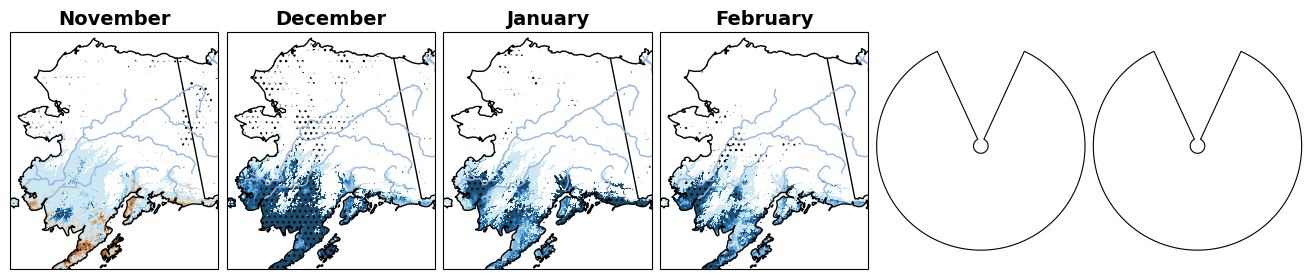

In [23]:
import matplotlib.colors as mcolors

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65)
    )
}

fig, axs = plt.subplots(
    nrows=1,
    ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True
)

vmin, vmax = -100, 100


for ax, (data, pvals, title) in zip(axs, datasets):

    # If params dimension exists, select pct_change
    if 'params' in data.dims:
        data = data.sel(params='pct_change')

    pcm = ax.pcolormesh(
        lon,
        lat,
        data,
        cmap=ros_colorbar,
        norm=mcolors.TwoSlopeNorm(
            vmin=vmin,
            vcenter=0,
            vmax=vmax
        ),
        shading='auto',
        transform=ccrs.PlateCarree()
    )


    # Significance stippling
    sig = pvals < 0.05

    ax.contourf(
        lon,
        lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )


    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.add_feature(
        cfeature.BORDERS,
        zorder=8
    )

    ax.add_feature(
        cfeature.COASTLINE,
        zorder=8
    )

    ax.add_feature(
        cfeature.RIVERS,
        zorder=8
    )

    ax.set_extent(
        [-165.3, -141, 55.8, 71.38],
        crs=ccrs.PlateCarree()
    )

    ax.set_aspect('equal')


# Overall title
fig.suptitle(
    "Percent Change in ROS Hours (1950–2022)",
    fontsize=16,
    y=0.83
)

fig.text(
    0.5,
    0.75,
    "Stippling indicates p < 0.05",
    ha='center',
    fontsize=13
)


# Colorbar
cbar = fig.colorbar(
    pcm,
    ax=axs,
    orientation='horizontal',
    fraction=0.08,
    pad=0.08,
    extend='both'
)

cbar.set_label(
    "Total Change in ROS Hours (%)"
)

cbar.set_ticks(
    np.arange(-100, 101, 20))

# Panel labels
fig.text(0.01, 0.64, 'A', fontsize=18, va='top', ha='left')
fig.text(0.175, 0.64, 'B', fontsize=18, va='top', ha='left')
fig.text(0.34, 0.64, 'C', fontsize=18, va='top', ha='left')
fig.text(0.51, 0.64, 'D', fontsize=18, va='top', ha='left')
fig.text(0.675, 0.64, 'E', fontsize=18, va='top', ha='left')
fig.text(0.84, 0.64, 'F', fontsize=18, va='top', ha='left')

fig.patch.set_alpha(0.0)

plt.show()

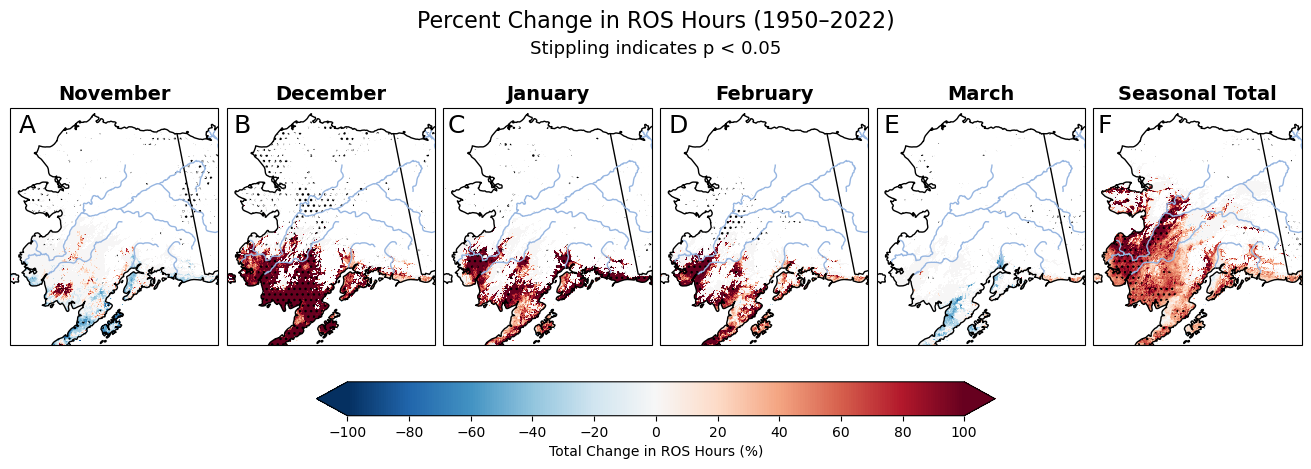

In [ ]:
import matplotlib.colors as mcolors

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65)
    )
}

fig, axs = plt.subplots(
    nrows=1,
    ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True
)

vmin, vmax = -100, 100


for ax, (data, pvals, title) in zip(axs, datasets):

    # If params dimension exists, select pct_change
    if 'params' in data.dims:
        data = data.sel(params='pct_change')

    pcm = ax.pcolormesh(
        lon,
        lat,
        data,
        cmap='RdBu_r',
        norm=mcolors.TwoSlopeNorm(
            vmin=vmin,
            vcenter=0,
            vmax=vmax
        ),
        shading='auto',
        transform=ccrs.PlateCarree()
    )


    # Significance stippling
    sig = pvals < 0.05

    ax.contourf(
        lon,
        lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )


    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.add_feature(
        cfeature.BORDERS,
        zorder=8
    )

    ax.add_feature(
        cfeature.COASTLINE,
        zorder=8
    )

    ax.add_feature(
        cfeature.RIVERS,
        zorder=8
    )

    ax.set_extent(
        [-165.3, -141, 55.8, 71.38],
        crs=ccrs.PlateCarree()
    )

    ax.set_aspect('equal')


# Overall title
fig.suptitle(
    "Percent Change in ROS Hours (1950–2022)",
    fontsize=16,
    y=0.83
)

fig.text(
    0.5,
    0.75,
    "Stippling indicates p < 0.05",
    ha='center',
    fontsize=13
)


# Colorbar
cbar = fig.colorbar(
    pcm,
    ax=axs,
    orientation='horizontal',
    fraction=0.08,
    pad=0.08,
    extend='both'
)

cbar.set_label(
    "Total Change in ROS Hours (%)"
)

cbar.set_ticks(
    np.arange(-100, 101, 20)
)


# Panel labels
fig.text(0.01, 0.64, 'A', fontsize=18, va='top', ha='left')
fig.text(0.175, 0.64, 'B', fontsize=18, va='top', ha='left')
fig.text(0.34, 0.64, 'C', fontsize=18, va='top', ha='left')
fig.text(0.51, 0.64, 'D', fontsize=18, va='top', ha='left')
fig.text(0.675, 0.64, 'E', fontsize=18, va='top', ha='left')
fig.text(0.84, 0.64, 'F', fontsize=18, va='top', ha='left')


fig.patch.set_alpha(0.0)

plt.show()

In [ ]:
import matplotlib.colors as mcolors

AK_ALBERS_SUBPLOT_KW = {
    'projection': ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65)
    )
}

fig, axs = plt.subplots(
    nrows=1,
    ncols=6,
    figsize=(13, 5.5),
    subplot_kw=AK_ALBERS_SUBPLOT_KW,
    constrained_layout=True
)

vmin, vmax = -100, 100


for ax, (data, pvals, title) in zip(axs, datasets):

    # If params dimension exists, select pct_change
    if 'params' in data.dims:
        data = data.sel(params='pct_change')

    pcm = ax.pcolormesh(
        lon,
        lat,
        data,
        cmap='RdBu_r',
        norm=mcolors.TwoSlopeNorm(
            vmin=vmin,
            vcenter=0,
            vmax=vmax
        ),
        shading='auto',
        transform=ccrs.PlateCarree()
    )


    # Significance stippling
    sig = pvals < 0.05

    ax.contourf(
        lon,
        lat,
        sig,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['...'],
        transform=ccrs.PlateCarree()
    )


    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.add_feature(
        cfeature.BORDERS,
        zorder=8
    )

    ax.add_feature(
        cfeature.COASTLINE,
        zorder=8
    )

    ax.add_feature(
        cfeature.RIVERS,
        zorder=8
    )

    ax.set_extent(
        [-165.3, -141, 55.8, 71.38],
        crs=ccrs.PlateCarree()
    )

    ax.set_aspect('equal')


# Overall title
fig.suptitle(
    "Percent Change in ROS Hours (1950–2022)",
    fontsize=16,
    y=0.83
)

fig.text(
    0.5,
    0.75,
    "Stippling indicates p < 0.05",
    ha='center',
    fontsize=13
)


# Colorbar
cbar = fig.colorbar(
    pcm,
    ax=axs,
    orientation='horizontal',
    fraction=0.08,
    pad=0.08,
    extend='both'
)

cbar.set_label(
    "Total Change in ROS Hours (%)"
)

cbar.set_ticks(
    np.arange(-100, 101, 20)
)


# Panel labels
fig.text(0.01, 0.64, 'A', fontsize=18, va='top', ha='left')
fig.text(0.175, 0.64, 'B', fontsize=18, va='top', ha='left')
fig.text(0.34, 0.64, 'C', fontsize=18, va='top', ha='left')
fig.text(0.51, 0.64, 'D', fontsize=18, va='top', ha='left')
fig.text(0.675, 0.64, 'E', fontsize=18, va='top', ha='left')
fig.text(0.84, 0.64, 'F', fontsize=18, va='top', ha='left')


fig.patch.set_alpha(0.0)

plt.show()